# Chess Engine: 8x8 Board

Pieces: King (K), Queen (Q), Rook (R), Bishop (B), Knight (N), Pawn (P).

Conventions:
- Board is an 8x8 grid of squares indexed `board[row][col]`, `row, col` in `0..7`.
- `row 0` is Black's side (top when displayed), `row 7` is White's side (bottom).
- Each square is either `None` (empty) or a tuple `(piece_letter, color)`, e.g. `('K', 'w')`, `('P', 'b')`.
- King capture does **not** end the game here — the King is just a normal piece.
- **Pawns are simplified**: one square forward only into an empty square, diagonal capture only, no double-step from the start, no promotion, no en passant.
- White always moves first. The engine looks 1 ply ahead for White, then 1 ply ahead for Black's best reply (a 2-ply minimax), so it can see immediate recaptures.

**If you're comparing this against a real engine (e.g. Lichess):** this engine has no check/checkmate rules (Kings can be captured like any other piece), Pawns can't promote/en-passant/double-step, and the search only looks 2 plies deep — it will legitimately disagree with a real engine on anything that needs those rules or more lookahead. That's an expected limitation of this toy engine, not a bug.

Each step below is its own function, with a self-contained consistency check right after it. Run the cells in order.

In [302]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

np.random.seed(0)

## Piece values and board size

In [303]:
PIECE_VALUES = {'K': 2, 'Q': 9, 'R': 5, 'B': 3, 'N': 3, 'P': 1}
N = 8  # board dimension (8x8)

## Board setup

`create_board()` is where you hand-specify the starting position. Edit the assignments inside it to place whatever pieces you want.

In [ ]:
def empty_board():
    return [[None for _ in range(N)] for _ in range(N)]


def create_board():
    """Hand-specify the starting position here as an 8x8 grid, one row per
    line -- row 0 (top) is Black's side, row 7 (bottom) is White's side,
    column 0 (left) to column 7 (right), matching how a board looks on
    screen. Each square is either None or (piece_letter, color).
    Currently set to the standard chess starting position -- edit the
    squares directly to match whatever position you're testing.
    """
    board = [
        [('R','b'), ('N','b'), ('B','b'), ('Q','b'), ('K','b'), ('B','b'), ('N','b'), ('R','b')],
        [('P','b'), ('P','b'), ('P','b'), ('P','b'), None, ('P','b'), None, ('P','b')],
        [None     , ('P','b')     , ('P','b'), ('P','b'), ('P','b'), None, ('P','b'), None],
        [('P','b')     , ('P','b')     , ('P','b')     , ('P','b')     , None     , None     , ('B','w')     , None     ],
        [None     , ('Q','w')     , None     , None     , None     , None     , ('P','w')     , None     ],
        [None     , None     , None     , None     , None     , None     , None     , None     ],
        [('P','w'), ('P','w'), ('P','w'), ('P','w'), ('P','w'), ('P','w'), ('P','w'), ('P','w')],
        [('R','w'), ('N','w'), ('B','w'), ('Q','w'), ('K','w'), ('B','w'), ('N','w'), ('R','w')],
    ]
    return board

In [305]:
def display_board(board):
    fig, ax = plt.subplots(figsize=(4, 4))
    for row in range(N):
        for col in range(N):
            square_color = '#EEEEEE' if (row + col) % 2 == 0 else '#888888'
            ax.add_patch(plt.Rectangle((col, N - 1 - row), 1, 1, color=square_color))
            piece = board[row][col]
            if piece is not None:
                symbol, side = piece
                text_color = 'white' if side == 'w' else 'black'
                outline_color = 'black' if side == 'w' else 'white'
                ax.text(col + 0.5, N - 1 - row + 0.5, symbol,
                        ha='center', va='center', fontsize=28, fontweight='bold',
                        color=text_color,
                        path_effects=[pe.withStroke(linewidth=2, foreground=outline_color)])
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    plt.show()

### Run: build and display the board

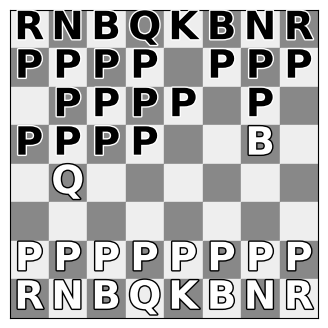

In [306]:
board = create_board()
display_board(board)

## Chess rules: move generation

No check/checkmate logic — a King can move into or be captured on any square like any other piece.

In [307]:
def in_bounds(r, c):
    return 0 <= r < N and 0 <= c < N


def king_moves(board, pos):
    r, c = pos
    _, color = board[r][c]
    moves = []
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue
            nr, nc = r + dr, c + dc
            if in_bounds(nr, nc):
                target = board[nr][nc]
                if target is None or target[1] != color:
                    moves.append((nr, nc))
    return moves


def knight_moves(board, pos):
    r, c = pos
    _, color = board[r][c]
    deltas = [(-2, -1), (-2, 1), (-1, -2), (-1, 2), (1, -2), (1, 2), (2, -1), (2, 1)]
    moves = []
    for dr, dc in deltas:
        nr, nc = r + dr, c + dc
        if in_bounds(nr, nc):
            target = board[nr][nc]
            if target is None or target[1] != color:
                moves.append((nr, nc))
    return moves


def pawn_moves(board, pos):
    """Simplified: one square forward into an empty square, diagonal capture
    only, no double-step, no promotion, no en passant."""
    r, c = pos
    _, color = board[r][c]
    direction = -1 if color == 'w' else 1  # White advances toward row 0, Black toward row N-1
    moves = []
    nr, nc = r + direction, c
    if in_bounds(nr, nc) and board[nr][nc] is None:
        moves.append((nr, nc))
    for dc in (-1, 1):
        nr, nc = r + direction, c + dc
        if in_bounds(nr, nc):
            target = board[nr][nc]
            if target is not None and target[1] != color:
                moves.append((nr, nc))
    return moves


def sliding_moves(board, pos, directions):
    r, c = pos
    _, color = board[r][c]
    moves = []
    for dr, dc in directions:
        nr, nc = r + dr, c + dc
        while in_bounds(nr, nc):
            target = board[nr][nc]
            if target is None:
                moves.append((nr, nc))
            else:
                if target[1] != color:
                    moves.append((nr, nc))
                break
            nr += dr
            nc += dc
    return moves


def bishop_moves(board, pos):
    return sliding_moves(board, pos, [(-1, -1), (-1, 1), (1, -1), (1, 1)])


def rook_moves(board, pos):
    return sliding_moves(board, pos, [(-1, 0), (1, 0), (0, -1), (0, 1)])


def queen_moves(board, pos):
    return bishop_moves(board, pos) + rook_moves(board, pos)


def piece_moves(board, pos):
    piece, _ = board[pos[0]][pos[1]]
    if piece == 'K':
        return king_moves(board, pos)
    if piece == 'P':
        return pawn_moves(board, pos)
    if piece == 'N':
        return knight_moves(board, pos)
    if piece == 'B':
        return bishop_moves(board, pos)
    if piece == 'R':
        return rook_moves(board, pos)
    if piece == 'Q':
        return queen_moves(board, pos)
    raise ValueError("Unknown piece " + piece)


def all_legal_moves(board, color):
    moves = []
    for r in range(N):
        for c in range(N):
            piece = board[r][c]
            if piece is not None and piece[1] == color:
                for dest in piece_moves(board, (r, c)):
                    moves.append(((r, c), dest))
    return moves


def apply_move(board, move):
    (r0, c0), (r1, c1) = move
    new_board = [row[:] for row in board]
    new_board[r1][c1] = new_board[r0][c0]
    new_board[r0][c0] = None
    return new_board

### Consistency check: move counts on a bare board

Each of these is a hand-countable fact about a single piece on an otherwise empty board, expressed in terms of the board size `N` so it stays correct at any board size.

In [308]:
b = empty_board()
b[0][0] = ('K', 'w')
assert len(king_moves(b, (0, 0))) == 3, "King in a corner should have exactly 3 moves"

b = empty_board()
b[1][1] = ('R', 'w')
expected_rook_moves = 2 * (N - 1)
assert len(rook_moves(b, (1, 1))) == expected_rook_moves, f"Rook on an empty {N}x{N} board should always have {expected_rook_moves} moves"

b = empty_board()
b[0][0] = ('N', 'w')
assert len(knight_moves(b, (0, 0))) == 2, "Knight in a corner should have exactly 2 moves"

b = empty_board()
b[0][0] = ('B', 'w')
expected_bishop_moves = N - 1
assert len(bishop_moves(b, (0, 0))) == expected_bishop_moves, f"Bishop in a corner of an {N}x{N} board should have exactly {expected_bishop_moves} moves (one diagonal)"

b = empty_board()
b[4][4] = ('P', 'w')
assert len(pawn_moves(b, (4, 4))) == 1, "A lone Pawn should have exactly 1 (forward) move"

b = empty_board()
b[4][4] = ('P', 'w')
b[3][3] = ('B', 'b')
b[3][5] = ('N', 'b')
assert len(pawn_moves(b, (4, 4))) == 3, "Pawn should have 1 forward move plus 2 diagonal captures"

b = empty_board()
b[4][4] = ('P', 'w')
b[3][4] = ('K', 'b')
assert len(pawn_moves(b, (4, 4))) == 0, "Pawn cannot move or capture straight ahead into an occupied square"

print("All move-generation checks passed.")

All move-generation checks passed.


## Evaluation function

In [309]:
def evaluate(board):
    score = 0
    for row in board:
        for piece in row:
            if piece is not None:
                symbol, color = piece
                value = PIECE_VALUES[symbol]
                score += value if color == 'w' else -value
    return score

### Consistency check: evaluation is exactly White's material minus Black's

In [310]:
b = empty_board()
b[0][0] = ('K', 'w')
b[3][3] = ('R', 'b')
expected = PIECE_VALUES['K'] - PIECE_VALUES['R']
assert evaluate(b) == expected, f"Expected {expected}, got {evaluate(b)}"
print("Evaluation check passed:", evaluate(b))

Evaluation check passed: -3


## Search: best move for White (2-ply minimax)

For each White move, look at every Black reply and take the **worst** (minimum) resulting score — assume Black plays its best response, not an average one. Then pick the White move with the highest worst-case score.

In [311]:
def best_move_for_white(board):
    white_moves = all_legal_moves(board, 'w')
    if not white_moves:
        raise ValueError("White has no legal moves")

    best_move = None
    best_score = -float('inf')
    for move in white_moves:
        after_white = apply_move(board, move)
        black_moves = all_legal_moves(after_white, 'b')
        if black_moves:
            worst_case = min(evaluate(apply_move(after_white, bm)) for bm in black_moves)
        else:
            worst_case = evaluate(after_white)
        if worst_case > best_score:
            best_score = worst_case
            best_move = move
    return best_move, best_score

### Run: find White's best move on the board above

In [312]:
move, score = best_move_for_white(board)
print(f"Best move for White: {move}, worst-case score: {score}")

Best move for White: ((3, 6), (0, 3)), worst-case score: 4


### Consistency check: the search takes free pieces and avoids bad trades

**Check A — free capture:** White's Rook can take Black's Bishop with no possible recapture. The engine must choose that capture.

**Check B — avoid the trap:** White's Rook *could* capture Black's Knight, but Black's Queen defends it and would recapture, losing White's Rook for only a Knight. A quiet King move that keeps material equal is better. The engine must NOT choose the capture.

In [313]:
# Check A: free capture, no recapture possible
b = empty_board()
b[0][3] = ('K', 'w')
b[3][0] = ('R', 'w')
b[0][0] = ('K', 'b')
b[3][3] = ('B', 'b')
move, score = best_move_for_white(b)
assert move == ((3, 0), (3, 3)), f"Expected the free Bishop capture, got {move}"
print("Check A passed: engine takes the free Bishop.", move, score)

# Check B: the obvious capture is a trap (Queen defends the Knight)
b = empty_board()
b[0][0] = ('K', 'w')
b[3][0] = ('R', 'w')
b[0][3] = ('K', 'b')
b[3][3] = ('N', 'b')
b[1][3] = ('Q', 'b')
move, score = best_move_for_white(b)
assert move != ((3, 0), (3, 3)), "Engine should NOT walk into the Queen-defended Knight"
assert score > -9, f"Engine should find a move better than the trap's outcome, got score {score}"
print("Check B passed: engine avoids the trap.", move, score)

Check A passed: engine takes the free Bishop. ((3, 0), (3, 3)) 5
Check B passed: engine avoids the trap. ((0, 0), (0, 1)) -7


## Learning piece values with gradient descent

The network is never told the standard piece values. It only knows one anchor: the Pawn is worth 1 (`P_VALUE`, fixed, never updated). For King, Rook, Bishop, Knight, and Queen it must discover its own values purely from being trained on *which move is correct* -- not from being handed the correct numbers.

The correct move for any position is still the deterministic 2-ply search we already built and verified, using the real, fixed piece values -- that never changes and is the "fixed answer" being trained on. What's learned is a substitute scoring function: reuse the exact same rules (legal moves, captures, whose turn) but evaluate material with the current guess `v` instead of `PIECE_VALUES`. Training is a **structured hinge loss**: the true best move's score (under the current `v`) must beat every other legal move's score by a margin; gradient descent nudges `v` to fix violations.

**Performance note:** for a given position, which moves are legal and what each one can capture never changes as `v` changes during training -- only the *value* assigned to the resulting material does. So each position's move/reply structure is computed once (`precompute_example`), and every training epoch after that is just cheap arithmetic (`X @ v`) over those cached feature vectors, instead of regenerating moves from scratch hundreds of times.

In [314]:
LEARNABLE_TYPES = ['K', 'R', 'B', 'N', 'Q']
P_VALUE = 1.0  # fixed anchor; never updated by gradient descent


def board_features(board):
    """Signed (White count - Black count) for each learnable piece type,
    plus the Pawn count kept separately since its value is fixed."""
    counts = {t: 0 for t in LEARNABLE_TYPES}
    pawn_count = 0
    for row in board:
        for piece in row:
            if piece is None:
                continue
            symbol, color = piece
            sign = 1 if color == 'w' else -1
            if symbol == 'P':
                pawn_count += sign
            else:
                counts[symbol] += sign
    x = np.array([counts[t] for t in LEARNABLE_TYPES], dtype=float)
    return x, pawn_count


def score_board(board, v):
    x, pawn_count = board_features(board)
    return float(np.dot(v, x) + P_VALUE * pawn_count)


def move_scores_under_v(board, v):
    """Live (uncached) scoring for a single one-off board -- used for the final
    comparison cell and spot checks, not inside the training loop."""
    results = []
    for move in all_legal_moves(board, 'w'):
        after_white = apply_move(board, move)
        black_moves = all_legal_moves(after_white, 'b')
        if black_moves:
            worst_reply = min(black_moves, key=lambda bm: score_board(apply_move(after_white, bm), v))
            worst_board = apply_move(after_white, worst_reply)
        else:
            worst_board = after_white
        x, _ = board_features(worst_board)
        results.append({'move': move, 'score': score_board(worst_board, v), 'x': x})
    return results


def precompute_example(board, true_move):
    """One-time-per-position work: for every White move, the feature vectors of
    every possible Black-reply terminal board. This doesn't depend on v, so it
    only needs to be computed once per position, not once per training epoch."""
    entries = []
    for move in all_legal_moves(board, 'w'):
        after_white = apply_move(board, move)
        black_moves = all_legal_moves(after_white, 'b')
        terminal_boards = [apply_move(after_white, bm) for bm in black_moves] if black_moves else [after_white]
        feats = [board_features(tb) for tb in terminal_boards]
        X = np.array([f[0] for f in feats])
        pc = np.array([f[1] for f in feats], dtype=float)
        entries.append({'move': move, 'X': X, 'pc': pc})
    true_entry = next(e for e in entries if e['move'] == true_move)
    return entries, true_entry


def worst_case(entry, v):
    """Vectorized: score every cached candidate terminal board at once, return
    the worst (Black's best reply) score and its feature vector."""
    scores = entry['X'] @ v + P_VALUE * entry['pc']
    idx = np.argmin(scores)
    return scores[idx], entry['X'][idx]

In [315]:
def hinge_loss_and_grad(entries, true_entry, v, margin=1.0):
    """Structured margin loss: the true best move's score must beat every
    other candidate move's score by `margin`. Violations push the gradient."""
    true_score, true_x = worst_case(true_entry, v)
    grad = np.zeros_like(v)
    total_loss = 0.0
    for e in entries:
        if e is true_entry:
            continue
        score, x = worst_case(e, v)
        violation = margin + score - true_score
        if violation > 0:
            total_loss += violation
            grad += (x - true_x)
    return total_loss, grad

In [316]:
def random_position(rng, min_extra=3, max_extra=8, min_pawns=2, max_pawns=6):
    """Random position: one King per side, a random number (min_extra..max_extra)
    of extra non-Pawn pieces (random type Q/R/B/N, random side), and a random
    number (min_pawns..max_pawns) of Pawns for EACH side, never on the back
    ranks. All on distinct squares, with White guaranteed a move."""
    all_squares = [(r, c) for r in range(N) for c in range(N)]
    pawn_squares = [(r, c) for r in range(1, N - 1) for c in range(N)]
    piece_types = ['Q', 'R', 'B', 'N']
    while True:
        extra_count = rng.integers(min_extra, max_extra + 1)
        white_pawns = rng.integers(min_pawns, max_pawns + 1)
        black_pawns = rng.integers(min_pawns, max_pawns + 1)

        pawn_idx = rng.choice(len(pawn_squares), size=white_pawns + black_pawns, replace=False)
        chosen_pawn_squares = [pawn_squares[i] for i in pawn_idx]
        used = set(chosen_pawn_squares)

        other_squares_pool = [s for s in all_squares if s not in used]
        idx = rng.choice(len(other_squares_pool), size=2 + extra_count, replace=False)
        other_squares = [other_squares_pool[i] for i in idx]

        board = empty_board()
        k = 0
        board[other_squares[k][0]][other_squares[k][1]] = ('K', 'w'); k += 1
        board[other_squares[k][0]][other_squares[k][1]] = ('K', 'b'); k += 1
        for _ in range(extra_count):
            piece_type = rng.choice(piece_types)
            color = rng.choice(['w', 'b'])
            r, c = other_squares[k]; k += 1
            board[r][c] = (piece_type, color)

        p = 0
        for _ in range(white_pawns):
            r, c = chosen_pawn_squares[p]; p += 1
            board[r][c] = ('P', 'w')
        for _ in range(black_pawns):
            r, c = chosen_pawn_squares[p]; p += 1
            board[r][c] = ('P', 'b')

        if all_legal_moves(board, 'w'):
            return board

In [317]:
def train(v, examples, lr=0.02, epochs=600, margin=1.0):
    """Full-batch (sub)gradient descent on the structured hinge loss, using
    precomputed per-position candidates so each epoch is cheap arithmetic
    instead of redoing move generation from scratch."""
    history = []
    for epoch in range(epochs):
        total_loss = 0.0
        grad_sum = np.zeros_like(v)
        for entries, true_entry in examples:
            loss, grad = hinge_loss_and_grad(entries, true_entry, v, margin)
            total_loss += loss
            grad_sum += grad
        v = v - lr * grad_sum / len(examples)
        history.append(total_loss / len(examples))
    return v, history


def accuracy(examples, v):
    """Fraction of positions where argmax under v matches the true best move."""
    correct = 0
    for entries, true_entry in examples:
        best = max(entries, key=lambda e: worst_case(e, v)[0])
        correct += (best is true_entry)
    return correct / len(examples)

### Run: generate training data and train `v` with gradient descent

In [318]:
rng = np.random.default_rng(0)
NUM_TRAIN = 500
NUM_TEST = 50

train_positions = [random_position(rng) for _ in range(NUM_TRAIN)]
train_labels = [best_move_for_white(b)[0] for b in train_positions]

test_positions = [random_position(rng) for _ in range(NUM_TEST)]
test_labels = [best_move_for_white(b)[0] for b in test_positions]

print(f"Training on {NUM_TRAIN} random positions, testing on {NUM_TEST} held-out positions "
      f"(2 Kings, 3-8 extra Q/R/B/N pieces, and 2-6 Pawns per side).")

# Move/reply structure doesn't depend on v, so compute it once per position.
train_examples = [precompute_example(b, m) for b, m in zip(train_positions, train_labels)]
test_examples = [precompute_example(b, m) for b, m in zip(test_positions, test_labels)]

v0 = rng.uniform(0, 5, size=len(LEARNABLE_TYPES))  # random start, no hint of the true order
print("Initial (random) values:", dict(zip(LEARNABLE_TYPES, v0)))

v_trained, history = train(v0.copy(), train_examples, lr=0.02, epochs=600, margin=1.0)

train_acc = accuracy(train_examples, v_trained)
test_acc = accuracy(test_examples, v_trained)

print("Learned values (P fixed at 1):", dict(zip(LEARNABLE_TYPES, v_trained)))
print(f"Train move accuracy: {train_acc:.2%}")
print(f"Test move accuracy:  {test_acc:.2%}")

Training on 500 random positions, testing on 50 held-out positions (2 Kings, 3-8 extra Q/R/B/N pieces, and 2-6 Pawns per side).
Initial (random) values: {'K': np.float64(4.607092985653618), 'R': np.float64(0.602306940562029), 'B': np.float64(1.4600007606043812), 'N': np.float64(2.9928404920504414), 'Q': np.float64(4.870262008051652)}
Learned values (P fixed at 1): {'K': np.float64(2.0002929856536227), 'R': np.float64(3.6227469405620565), 'B': np.float64(2.623480760604353), 'N': np.float64(2.623200492050471), 'Q': np.float64(5.744022008051584)}
Train move accuracy: 94.60%
Test move accuracy:  96.00%


### Consistency check: does gradient descent recover sensible relative piece values?

The network is never told the true piece values, and only `v_P = 1` is fixed as a reference point. It should still (1) pick the same move as the true brute-force engine on most held-out positions, (2) discover Queen > Rook > {Bishop, Knight} > King without ever being told that ordering, and (3) still avoid a Queen-defended-piece trap it never trained on.

In [319]:
learned = dict(zip(LEARNABLE_TYPES, v_trained))

# The network was never told which pieces are more valuable than others,
# except that the Pawn is fixed at 1. It should still discover
# Queen > Rook > {Bishop, Knight} > King.
assert learned['Q'] > learned['R'], "expected learned Queen > Rook"
assert learned['R'] > learned['K'], "expected learned Rook > King"
assert learned['R'] > learned['B'], "expected learned Rook > Bishop"
assert learned['R'] > learned['N'], "expected learned Rook > Knight"
assert learned['B'] > learned['K'], "expected learned Bishop > King"
assert learned['N'] > learned['K'], "expected learned Knight > King"
assert learned['K'] > P_VALUE, "expected learned King > the fixed Pawn anchor"
assert test_acc >= 0.9, f"expected high held-out move accuracy, got {test_acc}"
print("Relative order check passed:", learned)

# Held-out trap: same shape as the engine's Check B, but never seen during training/testing.
# Rook could take a Knight, but a Queen defends it.
b = empty_board()
b[0][0] = ('K', 'w')
b[3][0] = ('R', 'w')
b[0][3] = ('K', 'b')
b[3][3] = ('N', 'b')
b[1][3] = ('Q', 'b')
results = move_scores_under_v(b, v_trained)
predicted = max(results, key=lambda r: r['score'])['move']
assert predicted != ((3, 0), (3, 3)), "learned v should also avoid the queen-defended knight trap"
print("Held-out trap check passed. Predicted move:", predicted)

Relative order check passed: {'K': np.float64(2.0002929856536227), 'R': np.float64(3.6227469405620565), 'B': np.float64(2.623480760604353), 'N': np.float64(2.623200492050471), 'Q': np.float64(5.744022008051584)}
Held-out trap check passed. Predicted move: ((0, 0), (0, 1))


### Loss curve (diagnostic)

Same mechanic as fitting a line's slope and intercept: gradient descent should push the average hinge loss down over training, not chase noise upward.

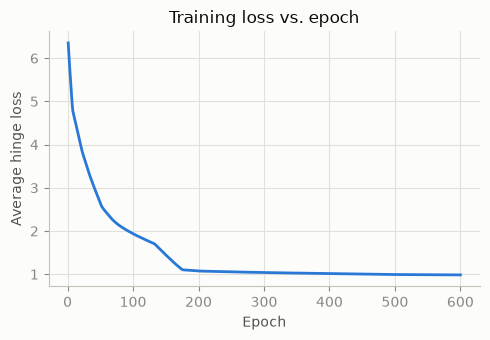

In [320]:
fig, ax = plt.subplots(figsize=(5, 3.5))
fig.patch.set_facecolor('#fcfcfb')
ax.set_facecolor('#fcfcfb')
ax.plot(range(1, len(history) + 1), history, color='#2a78d6', linewidth=2)
ax.set_title('Training loss vs. epoch', color='#0b0b0b', fontsize=12)
ax.set_xlabel('Epoch', color='#52514e')
ax.set_ylabel('Average hinge loss', color='#52514e')
ax.tick_params(colors='#898781')
ax.grid(True, color='#e1e0d9', linewidth=0.8)
for spine in ax.spines.values():
    spine.set_color('#c3c2b7')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Run: compare the true engine vs. the learned `v` on your own board

Uses the `board` you set up in `create_board()` above. Edit that cell and re-run everything to try a different position.

In [321]:
PIECE_NAMES = {'K': 'King', 'Q': 'Queen', 'R': 'Rook', 'B': 'Bishop', 'N': 'Knight', 'P': 'Pawn'}


def describe_move(board, move):
    """Human-readable description of a move: who moves, from where, to where,
    and what (if anything) it captures."""
    (r0, c0), (r1, c1) = move
    piece, color = board[r0][c0]
    side = 'White' if color == 'w' else 'Black'
    text = f"{side} {PIECE_NAMES[piece]} ({r0},{c0}) -> ({r1},{c1})"
    target = board[r1][c1]
    if target is not None:
        target_piece, target_color = target
        target_side = 'White' if target_color == 'w' else 'Black'
        text += f", capturing {target_side} {PIECE_NAMES[target_piece]}"
    return text

Starting position (from create_board()):


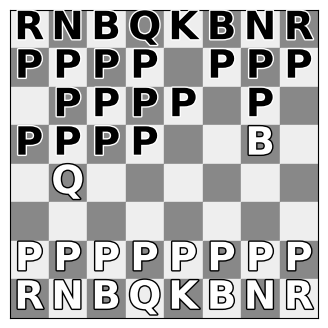


Piece values the network learned (trained on 500 random positions,
2 Kings, 3-8 extra Q/R/B/N, 2-6 Pawns/side; P fixed at 1.0, everything else discovered on its own):
  King   : 2.00  (true value: 2)
  Rook   : 3.62  (true value: 5)
  Bishop : 2.62  (true value: 3)
  Knight : 2.62  (true value: 3)
  Queen  : 5.74  (true value: 9)
  Pawn   : 1.00  (fixed, true value: 1)

True engine's move (used to generate the training labels):
  White Bishop (3,6) -> (0,3), capturing Black Queen | worst-case score: 4

Learned network's move (using its own discovered piece values):
  White Bishop (3,6) -> (0,3), capturing Black Queen | score under learned v: 0.37

Agree? True


In [322]:
print("Starting position (from create_board()):")
display_board(board)

true_move, true_score = best_move_for_white(board)
nn_results = move_scores_under_v(board, v_trained)
nn_move = max(nn_results, key=lambda r: r['score'])['move']
nn_score = max(r['score'] for r in nn_results)

print()
print("Piece values the network learned (trained on", NUM_TRAIN, "random positions,")
print(f"2 Kings, 3-8 extra Q/R/B/N, 2-6 Pawns/side; P fixed at {P_VALUE}, everything else discovered on its own):")
for t in LEARNABLE_TYPES:
    print(f"  {PIECE_NAMES[t]:7s}: {v_trained[LEARNABLE_TYPES.index(t)]:.2f}  (true value: {PIECE_VALUES[t]})")
print(f"  Pawn   : {P_VALUE:.2f}  (fixed, true value: {PIECE_VALUES['P']})")

print()
print("True engine's move (used to generate the training labels):")
print(" ", describe_move(board, true_move), f"| worst-case score: {true_score}")
print()
print("Learned network's move (using its own discovered piece values):")
print(" ", describe_move(board, nn_move), f"| score under learned v: {nn_score:.2f}")
print()
print("Agree?", true_move == nn_move)